In [1]:
import pandas as pd
import numpy as np
import os
import math
import glob
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

import src.data.dataprep as prep

In [2]:
# Import the base data and resample it from 5 minutes to hourly
nl_data = prep.dutch_data('../data/Dutchdata_clean/building_' + str(1) + '.parquet', 'h')
# Include net load for cost calculations
nl_data['net_load'] = nl_data['load'] - nl_data['solar_energy']
# Import a price profile and merge it with the consumption data
nl_price_data = pd.read_csv('../data/NL_DA_Prices.csv', index_col='Date',parse_dates=True, dayfirst=True)
nl_data = nl_data.merge(nl_price_data[['offtake', 'injection']], left_index=True, right_index=True)
# calculate the cost to be a positive net load x offtake minus a negative net load x injection
nl_data['cost'] = nl_data.apply(lambda row: row['net_load'] * row['injection'] if row['net_load'] < 0 else row['net_load'] * row['offtake'], axis=1)

In [3]:
buildings = []

folder_path = os.path.abspath(os.path.join(os.getcwd(), '../results/'))
file_paths = glob.glob(os.path.join(folder_path, '*'))
files = [os.path.basename(file_path) for file_path in file_paths]

In [4]:
files

['building_0_metrics.csv',
 'building_10_metrics.csv',
 'building_11_metrics.csv',
 'building_12_metrics.csv',
 'building_13_metrics.csv',
 'building_16_metrics.csv',
 'building_17_metrics.csv',
 'building_1_12kwh_metrics.csv',
 'building_1_15.0kwh_metrics.csv',
 'building_1_18kwh_metrics.csv',
 'building_1_21.0kwh_metrics.csv',
 'building_1_24kwh_metrics.csv',
 'building_1_27.0kwh_metrics.csv',
 'building_1_3.0kwh_metrics.csv',
 'building_1_30kwh_metrics.csv',
 'building_1_6kwh_metrics.csv',
 'building_1_9.0kwh_metrics.csv',
 'building_1_metrics.csv',
 'building_20_metrics.csv',
 'building_21_metrics.csv',
 'building_22_metrics.csv',
 'building_23_metrics.csv',
 'building_24_metrics.csv',
 'building_25_metrics.csv',
 'building_26_metrics.csv',
 'building_3_metrics.csv',
 'building_4_18kwh_metrics.csv',
 'building_4_27.0kwh_metrics.csv',
 'building_4_36kwh_metrics.csv',
 'building_4_45.0kwh_metrics.csv',
 'building_4_54kwh_metrics.csv',
 'building_4_9.0kwh_metrics.csv',
 'building_4_me

In [7]:
files = [file for file in files if "kwh" in file.lower()]
files = [file for file in files if "building_4" in file.lower()]

In [8]:
files

['building_4_18kwh_metrics.csv',
 'building_4_27.0kwh_metrics.csv',
 'building_4_36kwh_metrics.csv',
 'building_4_45.0kwh_metrics.csv',
 'building_4_54kwh_metrics.csv',
 'building_4_9.0kwh_metrics.csv']

In [9]:
dataframes = {}

# Loop through each file and read into a DataFrame
for file in files:  # Assuming filenames are building_0.csv to building_15.csv
    # Read the CSV
    df = pd.read_csv('../results/' + file, index_col=0)
    file_name = file.rstrip('kwh_metrics.csv')
    file_name = file_name.removeprefix('building_4_')
    # Store only the columns 'real' and 'rmse'
    dataframes[file_name] = df[['Cost']]

In [10]:
dataframes

{'18':                 Cost
 Model               
 LSTM      390.532678
 CVX       405.873112
 LSTM-CVX  388.907661
 NAIVE     412.613157
 PERFECT   240.763360,
 '27.0':                 Cost
 Model               
 LSTM      398.473807
 CVX       393.614165
 LSTM-CVX  384.925617
 NAIVE     428.123761
 PERFECT   212.795574,
 '36':                 Cost
 Model               
 LSTM      406.833234
 CVX       392.280281
 LSTM-CVX  381.629588
 NAIVE     439.146210
 PERFECT   197.519365,
 '45.0':                 Cost
 Model               
 LSTM      404.222593
 CVX       391.285789
 LSTM-CVX  386.536689
 NAIVE     444.871355
 PERFECT   188.054870,
 '54':                 Cost
 Model               
 LSTM      404.794548
 CVX       399.763348
 LSTM-CVX  387.096620
 NAIVE     445.676298
 PERFECT   182.502318,
 '9.0':                 Cost
 Model               
 LSTM      408.454540
 CVX       438.040230
 LSTM-CVX  428.985665
 NAIVE     417.690744
 PERFECT   308.634417}

In [11]:
# Convert dictionary to DataFrame
result_df = pd.concat(dataframes.values(), axis=1, keys=dataframes.keys())

# Flatten multi-level column names
result_df.columns = result_df.columns.get_level_values(0)

In [12]:
result_df

,18,27.0,36,45.0,54,9.0
Model,,,,,,
LSTM,390.532678,398.473807,406.833234,404.222593,404.794548,408.454540
CVX,405.873112,393.614165,392.280281,391.285789,399.763348,438.040230
LSTM-CVX,388.907661,384.925617,381.629588,386.536689,387.096620,428.985665
NAIVE,412.613157,428.123761,439.146210,444.871355,445.676298,417.690744
PERFECT,240.763360,212.795574,197.519365,188.054870,182.502318,308.634417


In [13]:
from sklearn.preprocessing import MinMaxScaler

# Initialize the scaler
scaler = MinMaxScaler()

# Apply MinMax scaling to each column separately
scaled_df = pd.DataFrame(scaler.fit_transform(result_df), columns=result_df.columns, index=result_df.index)

In [14]:
scaled_df = scaled_df.loc[:, sorted(scaled_df.columns, key=lambda x: float(x))]

In [15]:
scaled_df

,9.0,18,27.0,36,45.0,54
Model,,,,,,
LSTM,0.771373,0.871513,0.862303,0.866269,0.841721,0.844659
CVX,1.000000,0.960779,0.839735,0.806040,0.791347,0.825541
LSTM-CVX,0.930030,0.862057,0.799385,0.761961,0.772855,0.777411
NAIVE,0.842747,1.000000,1.000000,1.000000,1.000000,1.000000
PERFECT,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


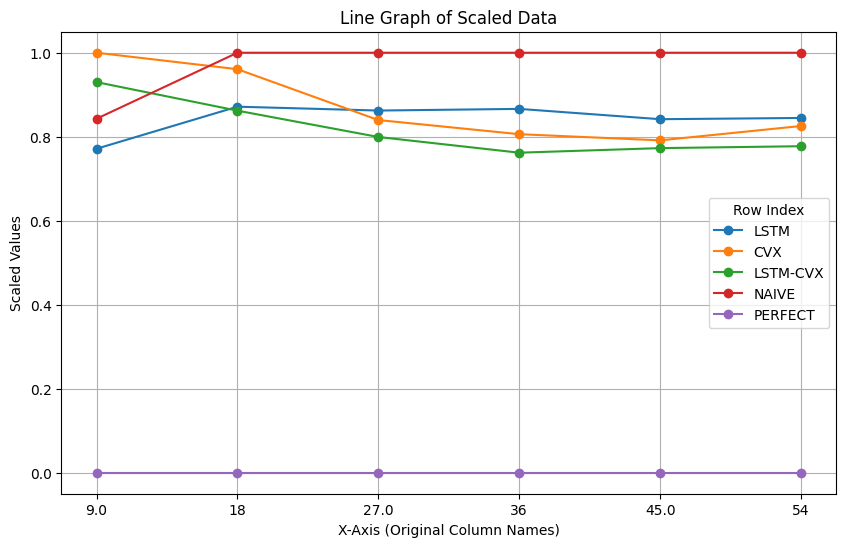

In [16]:
# Transpose the DataFrame so that columns (x-axis) become rows and vice versa
scaled_df.T.plot(kind="line", figsize=(10, 6), marker="o")

# Formatting the plot
plt.xlabel("X-Axis (Original Column Names)")
plt.ylabel("Scaled Values")
plt.title("Line Graph of Scaled Data")
plt.legend(title="Row Index")
plt.grid(True)

# Show the plot
plt.show()